## Analysing SegFormer segmentation model
---

In this notebook, we are going to fine-tune SegFormerForSemanticSegmentation on a custom semantic segmentation dataset. In semantic segmentation, the goal for the model is to label each pixel of an image with one of a list of predefined classes.

## Imports 
---

In [1]:
#external
import requests
import numpy as np
from PIL import Image
from tqdm.notebook import tqdm

#visualization
import matplotlib.pyplot as plt

#model
from transformers import SegformerImageProcessor, SegformerForSemanticSegmentation
import torch
from torch.utils.data import Dataset, DataLoader

#utils
from src.utils.dataset import load_foodseg103, decode_image_from_bytes

#constants
from src.constants.category_id import CATEGORY_ID

## Testing model
---

In [2]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model_name = "nvidia/segformer-b5-finetuned-ade-640-640"
processor = SegformerImageProcessor(do_resize=False)
model = SegformerForSemanticSegmentation.from_pretrained(model_name)
model.to(device);

In [3]:
url = "https://wallpapercave.com/wp/wp2781008.jpg"
image = Image.open(requests.get(url, stream=True).raw)
image = image.resize(size=(256, 256))

In [4]:
pixel_values = processor(image, return_tensors="pt").pixel_values.to(device)
with torch.no_grad():
  outputs = model(pixel_values)
  logits = outputs.logits

In [5]:
predicted_segmentation_map = processor.post_process_semantic_segmentation(outputs, target_sizes=[image.size[::-1]])[0]
predicted_segmentation_map = predicted_segmentation_map.cpu().numpy()

color_seg = np.zeros(
    (
        predicted_segmentation_map.shape[0],
        predicted_segmentation_map.shape[1],
        3
    ), dtype=np.uint8)

(-0.5, 255.5, 255.5, -0.5)

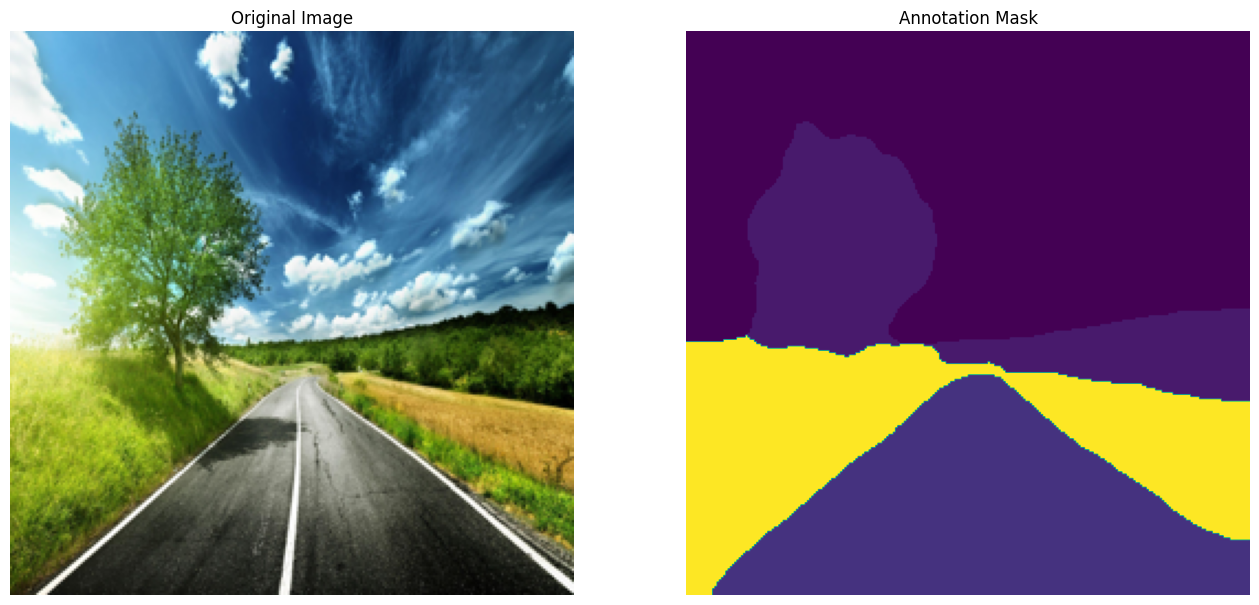

In [6]:
fig, axs = plt.subplots(1, 2, figsize=(16, 8))
axs[0].set_title('Original Image')
axs[1].set_title('Annotation Mask')
axs[0].axis('off')
axs[1].axis('off')

axs[0].imshow(image)
axs[0].axis('off')
axs[1].imshow(predicted_segmentation_map)
axs[1].axis("off")

## Testing on custom dataset
---

### Defining Dataset

In [7]:
class SemanticSegmentationFoodDataset(Dataset):
    def __init__(self, image_processor:SegformerImageProcessor, sample_size:int=None, data_type:str="train"):
        image_dataset = load_foodseg103(type=data_type, sample_size=sample_size)
        self.image_dataset = image_dataset
        self.image_processor = image_processor

    def __len__(self):
        return self.image_dataset.shape[0]
    
    def __getitem__(self, index):
        image_information = self.image_dataset.loc[index]
        image_decoded = decode_image_from_bytes(image_information["image"])
        mask = decode_image_from_bytes(image_information["label"])
        encoded_inputs = self.image_processor(image_decoded, mask, return_tensors="pt")
        for k,v in encoded_inputs.items():
          encoded_inputs[k].squeeze_() # remove batch dimension
        return encoded_inputs

In [8]:
image_processor = SegformerImageProcessor(do_reduce_labels=True)
train_dataset = SemanticSegmentationFoodDataset(image_processor, sample_size=1, data_type="train")
validation_dataset = SemanticSegmentationFoodDataset(image_processor, sample_size=1, data_type="validation")

In [9]:
print(f"Number of training examples: {train_dataset.__len__()}")
print(f"Number of training examples: {validation_dataset.__len__()}")

Number of training examples: 1
Number of training examples: 1


### Testing random example

In [10]:
image_example = train_dataset.__getitem__(0)
print(f"Image shape: {image_example["pixel_values"].shape}")
print(f"Image labels: {[CATEGORY_ID.get(i.item(), 'Unknown') for i in image_example["labels"].squeeze().unique()]}")

Image shape: torch.Size([3, 512, 512])
Image labels: ['peach', 'crab', 'eggplant', 'pepper', 'Unknown']


### Model definition

In [11]:
model = SegformerForSemanticSegmentation.from_pretrained(
    "nvidia/mit-b0",
    num_labels=len(CATEGORY_ID),
    id2label=CATEGORY_ID,
    label2id={v: k for k, v in CATEGORY_ID.items()},
)

Some weights of SegformerForSemanticSegmentation were not initialized from the model checkpoint at nvidia/mit-b0 and are newly initialized: ['decode_head.batch_norm.bias', 'decode_head.batch_norm.num_batches_tracked', 'decode_head.batch_norm.running_mean', 'decode_head.batch_norm.running_var', 'decode_head.batch_norm.weight', 'decode_head.classifier.bias', 'decode_head.classifier.weight', 'decode_head.linear_c.0.proj.bias', 'decode_head.linear_c.0.proj.weight', 'decode_head.linear_c.1.proj.bias', 'decode_head.linear_c.1.proj.weight', 'decode_head.linear_c.2.proj.bias', 'decode_head.linear_c.2.proj.weight', 'decode_head.linear_c.3.proj.bias', 'decode_head.linear_c.3.proj.weight', 'decode_head.linear_fuse.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


### Model training

In [12]:
train_dataloader = DataLoader(train_dataset, batch_size=8, shuffle=True)
validation_dataloader = DataLoader(validation_dataset, batch_size=8)

In [13]:
num_epochs = 100
optimizer = torch.optim.AdamW(model.parameters(), lr=0.0001)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device);

In [14]:
for epoch in range(num_epochs):
    for idx, batch in enumerate(tqdm(train_dataloader)):
        pixel_values = batch["pixel_values"].to(device)
        labels = batch["labels"].to(device)
        optimizer.zero_grad()
        outputs = model(pixel_values=pixel_values, labels=labels)
        loss, logits = outputs.loss, outputs.logits

        loss.backward()
        optimizer.step()

  0%|          | 0/1 [00:00<?, ?it/s]

  0%|          | 0/1 [00:00<?, ?it/s]

  0%|          | 0/1 [00:00<?, ?it/s]

  0%|          | 0/1 [00:00<?, ?it/s]

  0%|          | 0/1 [00:00<?, ?it/s]

...

  0%|          | 0/1 [00:00<?, ?it/s]

  0%|          | 0/1 [00:00<?, ?it/s]

  0%|          | 0/1 [00:00<?, ?it/s]

  0%|          | 0/1 [00:00<?, ?it/s]

  0%|          | 0/1 [00:00<?, ?it/s]

### Testing in new image

In [15]:
test_image = decode_image_from_bytes(train_dataset.image_dataset.loc[0]["image"])

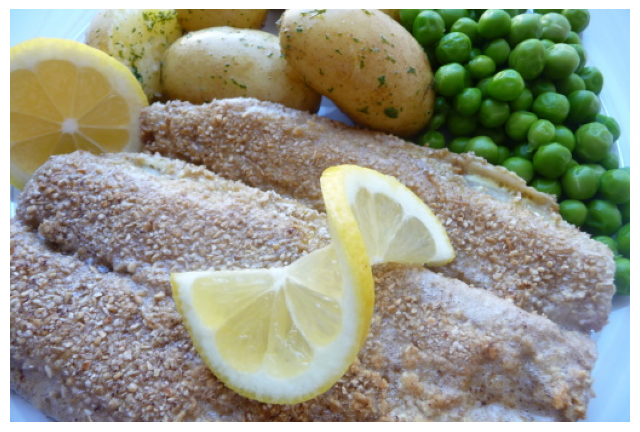

In [16]:
plt.figure(figsize=(8,6))
plt.imshow(test_image)
plt.axis('off')
plt.show()

In [17]:
pixel_values = image_processor(test_image, return_tensors="pt").pixel_values.to(device)
print(pixel_values.shape)

torch.Size([1, 3, 512, 512])


In [18]:
with torch.no_grad():
    outputs = model(pixel_values=pixel_values)

In [19]:
predicted_segmentation_map = image_processor.post_process_semantic_segmentation(outputs, target_sizes=[image.size[::-1]])[0]
predicted_segmentation_map = predicted_segmentation_map.cpu().numpy()
color_seg = np.zeros(
    (
        predicted_segmentation_map.shape[0],
        predicted_segmentation_map.shape[1],
        3
    ), dtype=np.uint8)


(-0.5, 255.5, 255.5, -0.5)

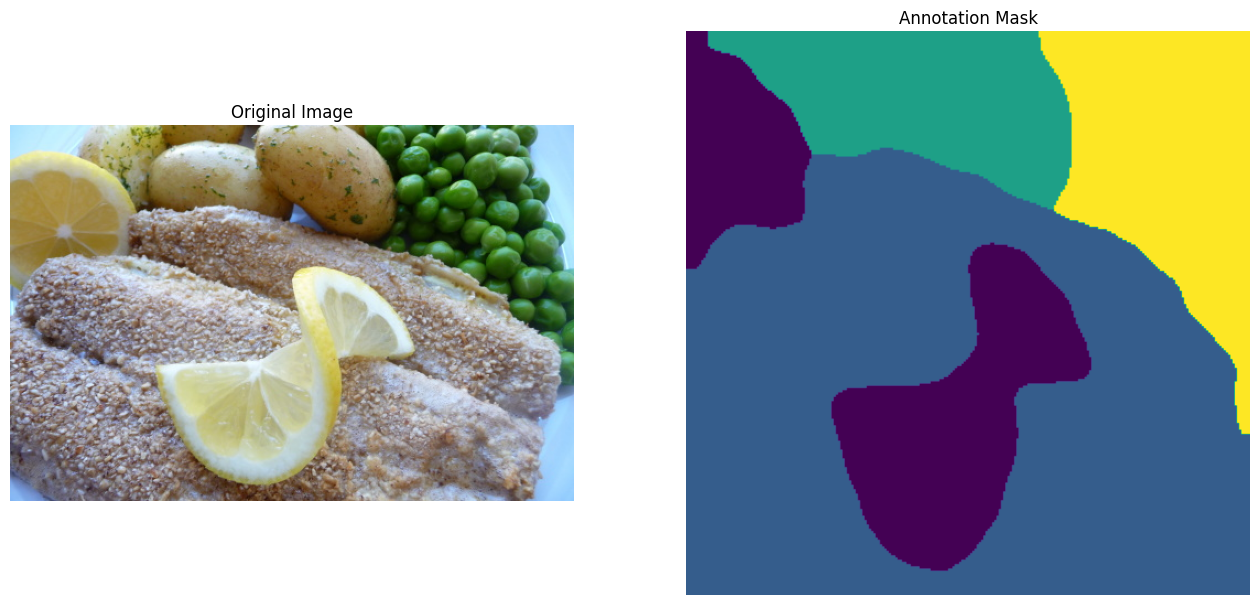

In [20]:
fig, axs = plt.subplots(1, 2, figsize=(16, 8))
axs[0].set_title('Original Image')
axs[1].set_title('Annotation Mask')
axs[0].axis('off')
axs[1].axis('off')

axs[0].imshow(test_image)
axs[0].axis('off')
axs[1].imshow(predicted_segmentation_map)
axs[1].axis("off")

## References
[1] https://github.com/NielsRogge/Transformers-Tutorials/tree/master/SegFormer